# Topic 9: Conditional Probability
**STOR 155 — Introduction to Data Models and Inference**

---

Conditional probability lets us **update probabilities with new information**. This is one of the most powerful and practical concepts in all of statistics.

**Key concepts:**
- Marginal vs. joint probabilities
- Law of Total Probability
- Conditional probability $P(A|B)$
- General Multiplication Rule
- Independence (revisited)
- Bayes' Theorem
- Probability trees
- Monty Hall Problem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(155)

---
## 1. Marginal & Joint Probabilities (Contingency Tables)

The course notes open with a contingency table about **student and parent smoking habits**:

|  | Parents: used | Parents: not | Total |
|--|:---:|:---:|:---:|
| **Student: uses** | 125 | 94 | 219 |
| **Student: not** | 85 | 141 | 226 |
| **Total** | 210 | 235 | 445 |

**Terminology:**
- **Joint probability**: probability of TWO things happening together (interior cells)
- **Marginal probability**: probability of ONE thing happening (totals row/column)

In [25]:
# Build the contingency table
data = np.array([[125, 94], [85, 141]])
smoking = pd.DataFrame(
    data,
    index=['Student: uses', 'Student: not'],
    columns=['Parents: used', 'Parents: not']
)

# Add totals
smoking['Total'] = smoking.sum(axis=1)
smoking.loc['Total'] = smoking.sum(axis=0)

print("Contingency Table (counts):")
display(smoking)
print(f"\nTotal individuals: {smoking.loc['Total', 'Total']}")

Contingency Table (counts):


,Parents: used,Parents: not,Total
Student: uses,125,94,219
Student: not,85,141,226
Total,210,235,445



Total individuals: 445


In [3]:
# Convert to probabilities (divide everything by total)
N = 445
prob_table = smoking / N

print("Probability Table:")
print(prob_table.round(4))

print("\n--- Joint Probabilities (interior cells) ---")
print(f"P(student uses AND parents used)     = 125/445 = {125/N:.4f}")
print(f"P(student uses AND parents not)       = 94/445  = {94/N:.4f}")
print(f"P(student not AND parents used)       = 85/445  = {85/N:.4f}")
print(f"P(student not AND parents not)        = 141/445 = {141/N:.4f}")

print("\n--- Marginal Probabilities (totals) ---")
print(f"P(student uses)    = 219/445 = {219/N:.4f}")
print(f"P(parents used)    = 210/445 = {210/N:.4f}")

Probability Table:
               Parents: used  Parents: not   Total
Student: uses         0.2809        0.2112  0.4921
Student: not          0.1910        0.3169  0.5079
Total                 0.4719        0.5281  1.0000

--- Joint Probabilities (interior cells) ---
P(student uses AND parents used)     = 125/445 = 0.2809
P(student uses AND parents not)       = 94/445  = 0.2112
P(student not AND parents used)       = 85/445  = 0.1910
P(student not AND parents not)        = 141/445 = 0.3169

--- Marginal Probabilities (totals) ---
P(student uses)    = 219/445 = 0.4921
P(parents used)    = 210/445 = 0.4719


### Law of Total Probability

A marginal probability = sum of its joint probabilities across the other variable.

$$P(\text{student uses}) = P(\text{student uses AND parents used}) + P(\text{student uses AND parents not})$$

In [4]:
# Law of Total Probability in action
p_student_uses = 125/N + 94/N
print(f"P(student uses) = P(uses & parents used) + P(uses & parents not)")
print(f"               = {125/N:.4f} + {94/N:.4f}")
print(f"               = {p_student_uses:.4f}")
print(f"               = 219/445 ✓")

P(student uses) = P(uses & parents used) + P(uses & parents not)
               = 0.2809 + 0.2112
               = 0.4921
               = 219/445 ✓


---
## 2. Conditional Probability

The **conditional probability** of $A$ given $B$ is:

$$P(A|B) = \frac{P(A \text{ and } B)}{P(B)}$$

**Intuition:** We "zoom in" on the world where $B$ has happened. $B$ becomes our new sample space, and we ask: what fraction of $B$ also has $A$?

Think of it as: **given that B happened, how likely is A?**

In [5]:
# From the smoking example:
# Q1: If parents smoked, what's the probability the student smokes?
#     P(student uses | parents used) = P(both) / P(parents used)

p_both = 125 / N
p_parents_used = 210 / N
p_student_given_parents = p_both / p_parents_used

print("Q1: P(student uses | parents used)")
print(f"   = P(student uses AND parents used) / P(parents used)")
print(f"   = (125/445) / (210/445)")
print(f"   = 125/210")
print(f"   = {p_student_given_parents:.4f}")
print(f"")
print(f"   Quick way: just look at the 'parents used' column → 125 out of 210")

print()

# Q2: If student does NOT smoke, what's the probability their parents smoked?
#     P(parents used | student not) = P(both) / P(student not)
p_parents_given_not_student = (85/N) / (226/N)
print("Q2: P(parents used | student does NOT use)")
print(f"   = 85/226 = {p_parents_given_not_student:.4f}")

Q1: P(student uses | parents used)
   = P(student uses AND parents used) / P(parents used)
   = (125/445) / (210/445)
   = 125/210
   = 0.5952

   Quick way: just look at the 'parents used' column → 125 out of 210

Q2: P(parents used | student does NOT use)
   = 85/226 = 0.3761


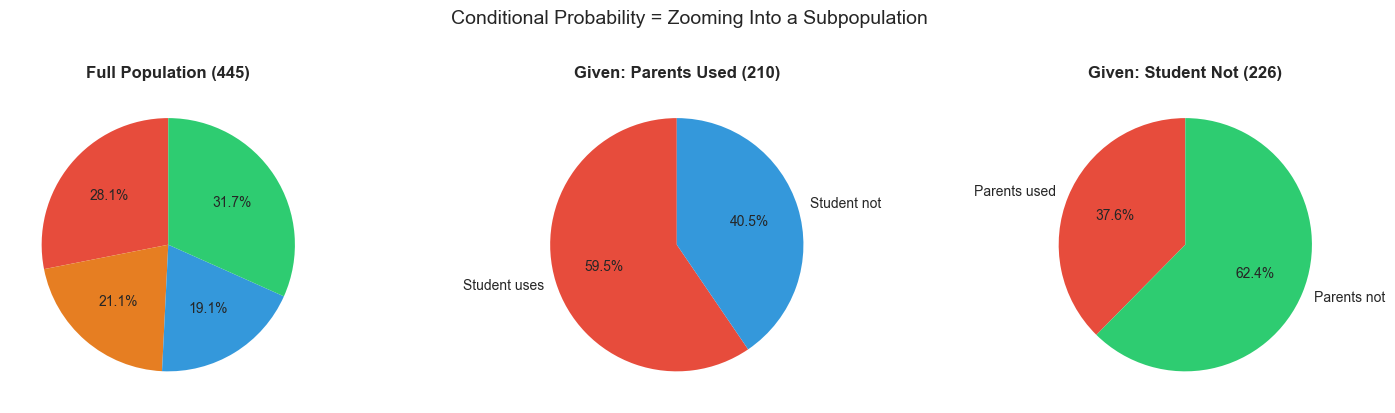

In [6]:
# Visualize: how conditioning changes our "world"
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full population
labels = ['Uses & Parents used', 'Uses & Parents not', 'Not & Parents used', 'Not & Parents not']
sizes = [125, 94, 85, 141]
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

axes[0].pie(sizes, labels=None, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Full Population (445)', fontsize=12, fontweight='bold')

# Given parents used (zoom into parents used column)
axes[1].pie([125, 85], labels=['Student uses', 'Student not'], colors=['#e74c3c', '#3498db'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Given: Parents Used (210)', fontsize=12, fontweight='bold')

# Given student not (zoom into student not row)
axes[2].pie([85, 141], labels=['Parents used', 'Parents not'], colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Given: Student Not (226)', fontsize=12, fontweight='bold')

plt.suptitle('Conditional Probability = Zooming Into a Subpopulation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Independence (Revisited)

Events $A$ and $B$ are **independent** if:

$$P(A|B) = P(A)$$

In other words: knowing $B$ happened gives you **no new information** about $A$.

This is equivalent to: $P(A \text{ and } B) = P(A) \cdot P(B)$

In [7]:
# Are student smoking and parent smoking independent?
p_student_uses = 219/445
p_student_given_parents = 125/210

print(f"P(student uses)                  = {p_student_uses:.4f}")
print(f"P(student uses | parents used)   = {p_student_given_parents:.4f}")
print(f"")
print(f"Are these equal? {abs(p_student_uses - p_student_given_parents) < 0.001}")
print(f"→ NOT independent! Knowing parents smoked INCREASES the probability.")
print(f"")
print(f"Difference: {p_student_given_parents - p_student_uses:.4f}")
print(f"Having smoking parents raises P(student smokes) by ~{(p_student_given_parents - p_student_uses)*100:.1f} percentage points.")

P(student uses)                  = 0.4921
P(student uses | parents used)   = 0.5952

Are these equal? False
→ NOT independent! Knowing parents smoked INCREASES the probability.

Difference: 0.1031
Having smoking parents raises P(student smokes) by ~10.3 percentage points.


---
## 4. Smallpox Example (from the notes)

**Boston smallpox outbreak, 1721:**

|  | Inoculated: yes | Inoculated: no | Total |
|--|:---:|:---:|:---:|
| **Lived** | 238 | 5136 | 5374 |
| **Died** | 6 | 844 | 850 |
| **Total** | 244 | 5980 | 6224 |

This is a classic example of how conditional probability reveals important relationships.

In [8]:
# Build the table
smallpox = pd.DataFrame(
    [[238, 5136], [6, 844]],
    index=['Lived', 'Died'],
    columns=['Inoculated', 'Not inoculated']
)
smallpox['Total'] = smallpox.sum(axis=1)
smallpox.loc['Total'] = smallpox.sum(axis=0)
print(smallpox)

N_sp = 6224
print("\n--- Key Conditional Probabilities ---")

# P(not inoculated AND died)
print(f"\nP(not inoculated AND died) = 844/{N_sp} = {844/N_sp:.4f}")

# P(died | not inoculated)
p_died_given_not_inoc = 844 / 5980
print(f"P(died | not inoculated)  = 844/5980 = {p_died_given_not_inoc:.4f} = {p_died_given_not_inoc*100:.2f}%")

# P(died | inoculated)
p_died_given_inoc = 6 / 244
print(f"P(died | inoculated)      = 6/244   = {p_died_given_inoc:.4f} = {p_died_given_inoc*100:.2f}%")

print(f"\nInoculation reduced death rate from {p_died_given_not_inoc*100:.1f}% to {p_died_given_inoc*100:.1f}%!")

       Inoculated  Not inoculated  Total
Lived         238            5136   5374
Died            6             844    850
Total         244            5980   6224

--- Key Conditional Probabilities ---

P(not inoculated AND died) = 844/6224 = 0.1356
P(died | not inoculated)  = 844/5980 = 0.1411 = 14.11%
P(died | inoculated)      = 6/244   = 0.0246 = 2.46%

Inoculation reduced death rate from 14.1% to 2.5%!


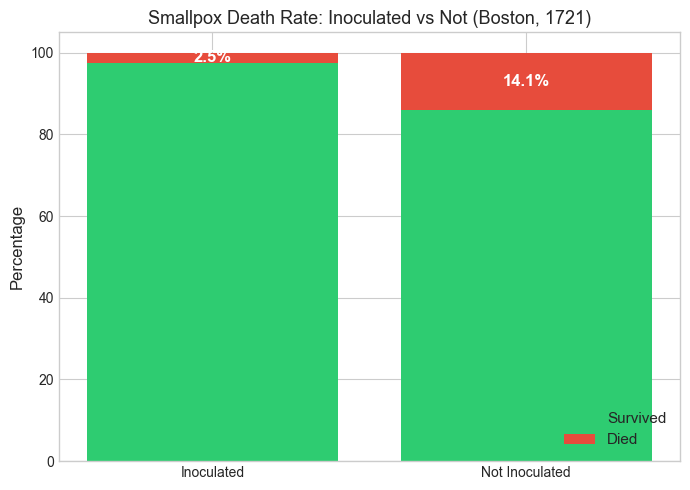

In [9]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Inoculated', 'Not Inoculated']
death_rates = [p_died_given_inoc * 100, p_died_given_not_inoc * 100]
survival_rates = [100 - d for d in death_rates]

bars_survived = ax.bar(categories, survival_rates, color='#2ecc71', label='Survived')
bars_died = ax.bar(categories, death_rates, bottom=survival_rates, color='#e74c3c', label='Died')

# Add percentage labels on the death portion
for i, (cat, dr) in enumerate(zip(categories, death_rates)):
    ax.text(i, survival_rates[i] + dr/2, f'{dr:.1f}%', ha='center', va='center', 
            fontsize=12, fontweight='bold', color='white')

ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Smallpox Death Rate: Inoculated vs Not (Boston, 1721)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

---
## 5. General Multiplication Rule

Rearranging the conditional probability formula:

$$P(A \text{ and } B) = P(B) \cdot P(A|B)$$

This works for ANY two events (not just independent ones).

When $A$ and $B$ are independent, $P(A|B) = P(A)$, so it simplifies to $P(A) \cdot P(B)$.

**Example from notes:** 96.08% of residents were not inoculated, and 85.88% of those who were not inoculated survived.

In [10]:
# General Multiplication Rule example
p_not_inoc = 5980 / 6224       # = 0.9608
p_survived_given_not_inoc = 5136 / 5980  # = 0.8588

p_not_inoc_and_survived = p_not_inoc * p_survived_given_not_inoc

print("General Multiplication Rule:")
print(f"P(not inoculated AND survived) = P(not inoculated) × P(survived | not inoculated)")
print(f"                               = {p_not_inoc:.4f} × {p_survived_given_not_inoc:.4f}")
print(f"                               = {p_not_inoc_and_survived:.4f}")
print(f"")
print(f"Verify: 5136/{N_sp} = {5136/N_sp:.4f}  ✓")

General Multiplication Rule:
P(not inoculated AND survived) = P(not inoculated) × P(survived | not inoculated)
                               = 0.9608 × 0.8589
                               = 0.8252

Verify: 5136/6224 = 0.8252  ✓


### Rules for Conditional Probabilities

All the basic probability rules still apply within conditional probabilities:

1. If $A$ and $B$ are **disjoint** and $C$ is another event:
   $$P(A \text{ or } B | C) = P(A|C) + P(B|C)$$

2. For **any** two events $A$ and $B$:
   $$P(A^c | B) = 1 - P(A|B)$$

In [11]:
# Example: P(died | not inoculated) using complement rule
p_survived_given_not = 5136 / 5980
p_died_given_not = 1 - p_survived_given_not

print(f"P(survived | not inoculated)  = {p_survived_given_not:.4f}")
print(f"P(died | not inoculated)      = 1 - {p_survived_given_not:.4f} = {p_died_given_not:.4f}")
print(f"Verify: 844/5980 = {844/5980:.4f}  ✓")

P(survived | not inoculated)  = 0.8589
P(died | not inoculated)      = 1 - 0.8589 = 0.1411
Verify: 844/5980 = 0.1411  ✓


---
## 6. Bayes' Theorem

Bayes' Theorem lets us **reverse the conditioning**:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

We often expand $P(B)$ using the **Law of Total Probability**:

$$P(B) = P(B|A) \cdot P(A) + P(B|A^c) \cdot P(A^c)$$

### Jar Example (from the notes)

- Flip a fair coin: Heads → Jar 1, Tails → Jar 2
- **Jar 1:** 3 white balls, 2 red balls
- **Jar 2:** 5 red balls, 1 blue ball
- Draw a ball at random.

**Question:** Given we drew a red ball, what's the probability the coin was heads (Jar 1)?

In [12]:
# Probability tree approach
# Step 1: Prior probabilities (before seeing the ball)
p_jar1 = 0.5  # P(Heads) = P(Jar 1)
p_jar2 = 0.5  # P(Tails) = P(Jar 2)

# Step 2: Likelihoods (probability of red given each jar)
p_red_given_jar1 = 2/5   # Jar 1 has 2 red out of 5
p_red_given_jar2 = 5/6   # Jar 2 has 5 red out of 6

# Step 3: Total probability of drawing red
p_red = p_red_given_jar1 * p_jar1 + p_red_given_jar2 * p_jar2

# Step 4: Bayes' Theorem
p_jar1_given_red = (p_red_given_jar1 * p_jar1) / p_red
p_jar2_given_red = (p_red_given_jar2 * p_jar2) / p_red

print("=== Probability Tree ===")
print(f"P(Jar 1) = {p_jar1}")
print(f"P(Jar 2) = {p_jar2}")
print(f"")
print(f"P(Red | Jar 1) = 2/5 = {p_red_given_jar1:.4f}")
print(f"P(Red | Jar 2) = 5/6 = {p_red_given_jar2:.4f}")
print(f"")
print(f"P(Red) = P(Red|J1)·P(J1) + P(Red|J2)·P(J2)")
print(f"       = {p_red_given_jar1:.4f}×{p_jar1} + {p_red_given_jar2:.4f}×{p_jar2}")
print(f"       = {p_red_given_jar1 * p_jar1:.4f} + {p_red_given_jar2 * p_jar2:.4f}")
print(f"       = {p_red:.4f}")
print(f"")
print(f"=== Bayes' Theorem ===")
print(f"P(Jar 1 | Red) = P(Red|J1)·P(J1) / P(Red)")
print(f"               = {p_red_given_jar1 * p_jar1:.4f} / {p_red:.4f}")
print(f"               = {p_jar1_given_red:.4f}")
print(f"")
print(f"P(Jar 2 | Red) = {p_jar2_given_red:.4f}")
print(f"")
print(f"Sanity check: {p_jar1_given_red:.4f} + {p_jar2_given_red:.4f} = {p_jar1_given_red + p_jar2_given_red:.4f} ✓")
print(f"")
print(f"Since Jar 2 has more red balls, drawing red makes Jar 2 MORE likely.")

=== Probability Tree ===
P(Jar 1) = 0.5
P(Jar 2) = 0.5

P(Red | Jar 1) = 2/5 = 0.4000
P(Red | Jar 2) = 5/6 = 0.8333

P(Red) = P(Red|J1)·P(J1) + P(Red|J2)·P(J2)
       = 0.4000×0.5 + 0.8333×0.5
       = 0.2000 + 0.4167
       = 0.6167

=== Bayes' Theorem ===
P(Jar 1 | Red) = P(Red|J1)·P(J1) / P(Red)
               = 0.2000 / 0.6167
               = 0.3243

P(Jar 2 | Red) = 0.6757

Sanity check: 0.3243 + 0.6757 = 1.0000 ✓

Since Jar 2 has more red balls, drawing red makes Jar 2 MORE likely.


In [13]:
# Verify with simulation!
n_sims = 200_000
results = []

for _ in range(n_sims):
    # Flip coin
    jar = np.random.choice([1, 2])
    
    # Draw from jar
    if jar == 1:
        ball = np.random.choice(['white', 'white', 'white', 'red', 'red'])
    else:
        ball = np.random.choice(['red', 'red', 'red', 'red', 'red', 'blue'])
    
    results.append((jar, ball))

df = pd.DataFrame(results, columns=['Jar', 'Ball'])

# P(Jar 1 | Red)
red_draws = df[df['Ball'] == 'red']
p_jar1_given_red_sim = (red_draws['Jar'] == 1).mean()

print(f"Simulation ({n_sims:,} trials):")
print(f"P(Jar 1 | Red) = {p_jar1_given_red_sim:.4f}  (theoretical: {p_jar1_given_red:.4f})")
print(f"P(Jar 2 | Red) = {1 - p_jar1_given_red_sim:.4f}  (theoretical: {p_jar2_given_red:.4f})")

Simulation (200,000 trials):
P(Jar 1 | Red) = 0.3239  (theoretical: 0.3243)
P(Jar 2 | Red) = 0.6761  (theoretical: 0.6757)


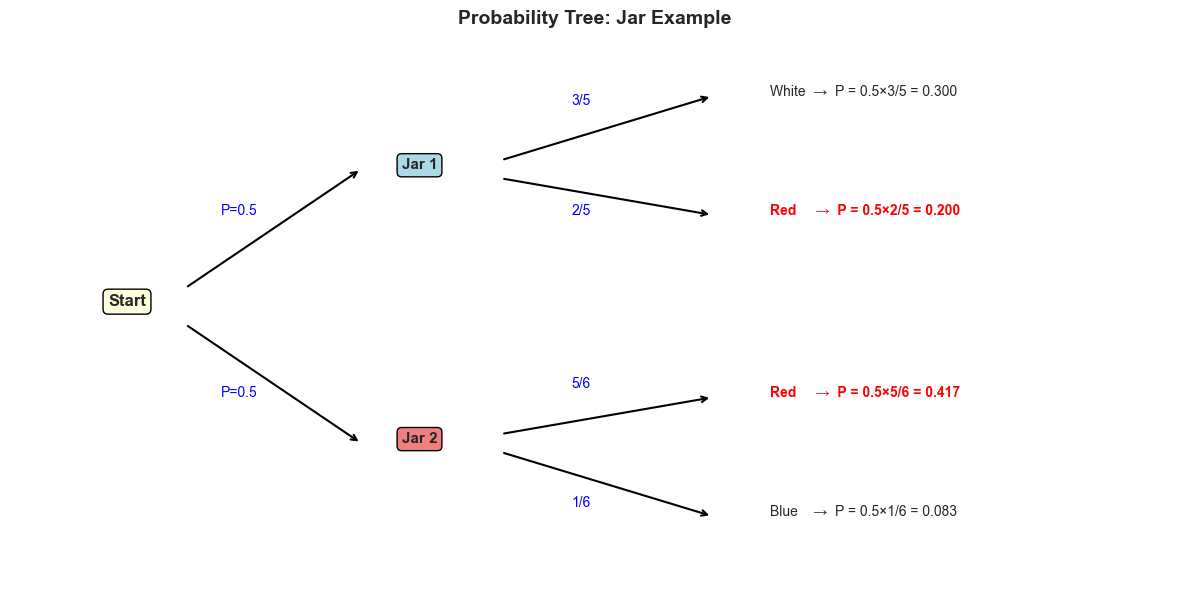

In [14]:
# Visualize the probability tree
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Probability Tree: Jar Example', fontsize=14, fontweight='bold')

# Tree structure
# Level 0: Start
ax.annotate('Start', xy=(1, 3), fontsize=12, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black'))

# Level 1: Jar choice
ax.annotate('', xy=(3, 4.5), xytext=(1.5, 3.2), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(3, 1.5), xytext=(1.5, 2.8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(1.8, 4.0, 'P=0.5', fontsize=10, color='blue')
ax.text(1.8, 2.0, 'P=0.5', fontsize=10, color='blue')

ax.annotate('Jar 1', xy=(3.5, 4.5), fontsize=11, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='black'))
ax.annotate('Jar 2', xy=(3.5, 1.5), fontsize=11, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='lightcoral', edgecolor='black'))

# Level 2: Ball color from Jar 1
ax.annotate('', xy=(6, 5.3), xytext=(4.2, 4.6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(6, 4.0), xytext=(4.2, 4.4), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(4.8, 5.2, '3/5', fontsize=10, color='blue')
ax.text(4.8, 4.0, '2/5', fontsize=10, color='blue')

ax.text(6.5, 5.3, 'White  →  P = 0.5×3/5 = 0.300', fontsize=10)
ax.text(6.5, 4.0, 'Red     →  P = 0.5×2/5 = 0.200', fontsize=10, color='red', fontweight='bold')

# Level 2: Ball color from Jar 2
ax.annotate('', xy=(6, 2.0), xytext=(4.2, 1.6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(6, 0.7), xytext=(4.2, 1.4), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(4.8, 2.1, '5/6', fontsize=10, color='blue')
ax.text(4.8, 0.8, '1/6', fontsize=10, color='blue')

ax.text(6.5, 2.0, 'Red     →  P = 0.5×5/6 = 0.417', fontsize=10, color='red', fontweight='bold')
ax.text(6.5, 0.7, 'Blue    →  P = 0.5×1/6 = 0.083', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Bayes' Theorem — General Form

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B|A) \cdot P(A) + P(B|A^c) \cdot P(A^c)}$$

**The Bayes thinking pattern:**
1. **Prior:** What did we believe before seeing data? → $P(A)$
2. **Likelihood:** How likely is the data under each hypothesis? → $P(B|A)$ vs $P(B|A^c)$  
3. **Posterior:** What do we believe AFTER seeing data? → $P(A|B)$

This is the foundation of **Bayesian statistics** and is used everywhere in machine learning!

In [15]:
def bayes_theorem(p_A, p_B_given_A, p_B_given_not_A):
    """Compute P(A|B) using Bayes' Theorem."""
    p_not_A = 1 - p_A
    p_B = p_B_given_A * p_A + p_B_given_not_A * p_not_A  # Law of Total Probability
    p_A_given_B = (p_B_given_A * p_A) / p_B
    return p_A_given_B, p_B

# Smallpox example reversed:
# Given that a randomly chosen resident died, what's the probability they were NOT inoculated?
p_not_inoc = 5980/6224
p_died_given_not_inoc = 844/5980
p_died_given_inoc = 6/244

p_not_inoc_given_died, p_died = bayes_theorem(p_not_inoc, p_died_given_not_inoc, p_died_given_inoc)

print("Smallpox: P(not inoculated | died)")
print(f"  Prior: P(not inoculated) = {p_not_inoc:.4f}")
print(f"  P(died | not inoculated) = {p_died_given_not_inoc:.4f}")
print(f"  P(died | inoculated)     = {p_died_given_inoc:.4f}")
print(f"  P(died)                  = {p_died:.4f}")
print(f"  ")
print(f"  Posterior: P(not inoculated | died) = {p_not_inoc_given_died:.4f}")
print(f"  Verify: 844/850 = {844/850:.4f}  ✓")

Smallpox: P(not inoculated | died)
  Prior: P(not inoculated) = 0.9608
  P(died | not inoculated) = 0.1411
  P(died | inoculated)     = 0.0246
  P(died)                  = 0.1366
  
  Posterior: P(not inoculated | died) = 0.9929
  Verify: 844/850 = 0.9929  ✓


---
## 8. The Monty Hall Problem

One of the most famous probability puzzles!

**Setup:**
- 3 doors: one has a car, two have goats
- You pick door 1
- The host (who KNOWS what's behind each door) opens door 3, revealing a goat
- **Should you switch to door 2, or stick with door 1?**

Most people's intuition says it doesn't matter (50/50). Let's see what simulation says...

In [16]:
def monty_hall_simulation(n_games=100_000):
    """Simulate the Monty Hall problem."""
    wins_switch = 0
    wins_stay = 0
    
    for _ in range(n_games):
        # Car is behind a random door (0, 1, or 2)
        car_door = np.random.randint(0, 3)
        
        # Player always picks door 0
        player_choice = 0
        
        # Host opens a door that is:
        #   (a) not the player's choice
        #   (b) not the car door
        available = [d for d in range(3) if d != player_choice and d != car_door]
        host_opens = np.random.choice(available)
        
        # Switch door = the remaining one
        switch_door = [d for d in range(3) if d != player_choice and d != host_opens][0]
        
        # Count wins
        if player_choice == car_door:
            wins_stay += 1
        if switch_door == car_door:
            wins_switch += 1
    
    return wins_stay / n_games, wins_switch / n_games

n_games = 100_000
p_stay, p_switch = monty_hall_simulation(n_games)

print(f"Monty Hall Simulation ({n_games:,} games):")
print(f"  Win rate by STAYING:    {p_stay:.4f}  (theoretical: 1/3 ≈ 0.3333)")
print(f"  Win rate by SWITCHING:  {p_switch:.4f}  (theoretical: 2/3 ≈ 0.6667)")
print(f"")
print(f"  → You should ALWAYS SWITCH! It doubles your chances!")

Monty Hall Simulation (100,000 games):
  Win rate by STAYING:    0.3332  (theoretical: 1/3 ≈ 0.3333)
  Win rate by SWITCHING:  0.6667  (theoretical: 2/3 ≈ 0.6667)

  → You should ALWAYS SWITCH! It doubles your chances!


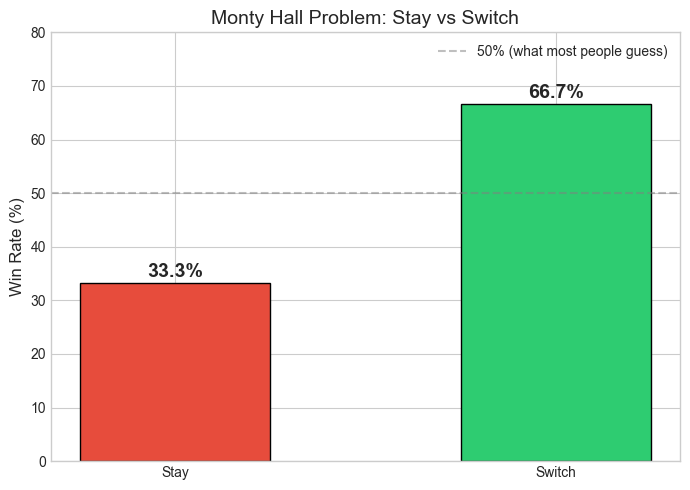


Why? Using Bayes' Theorem:
  When you first pick: P(car behind your door) = 1/3
  P(car behind other doors) = 2/3
  Host reveals a goat — but this doesn't change YOUR door's probability!
  The 2/3 probability concentrates onto the ONE remaining door.
  So switching gives you 2/3, staying gives you 1/3.


In [17]:
# Visualize the Monty Hall result
fig, ax = plt.subplots(figsize=(7, 5))

strategies = ['Stay', 'Switch']
win_rates = [p_stay * 100, p_switch * 100]
colors = ['#e74c3c', '#2ecc71']

bars = ax.bar(strategies, win_rates, color=colors, edgecolor='black', width=0.5)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% (what most people guess)')

for bar, rate in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('Monty Hall Problem: Stay vs Switch', fontsize=14)
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nWhy? Using Bayes' Theorem:")
print("  When you first pick: P(car behind your door) = 1/3")
print("  P(car behind other doors) = 2/3")
print("  Host reveals a goat — but this doesn't change YOUR door's probability!")
print("  The 2/3 probability concentrates onto the ONE remaining door.")
print("  So switching gives you 2/3, staying gives you 1/3.")

---
## 9. Spam-B-Gone: Applied Bayes (from the notes)

A spam classifier sorts emails into **H** (high-priority), **L** (low-priority), **S** (spam).

| Category | Count | Contains "offer" |
|----------|-------|------------------|
| H (high) | 200 | 4 |
| L (low) | 600 | 30 |
| S (spam) | 400 | 320 |
| **Total** | **1200** | **354** |

This is basically a **Naive Bayes classifier** — one of the simplest and most effective ML algorithms!

In [18]:
# Spam-B-Gone data
categories = {'H': {'total': 200, 'offer': 4},
              'L': {'total': 600, 'offer': 30},
              'S': {'total': 400, 'offer': 320}}
N_emails = 1200

# Q1: P(not spam) = P(H or L)
p_not_spam = (200 + 600) / N_emails
print(f"Q1: P(not spam) = (200+600)/1200 = {p_not_spam:.4f}")

# Q2: P(next email contains "offer")
# Law of Total Probability:
p_offer = sum(c['offer'] for c in categories.values()) / N_emails
print(f"\nQ2: P(contains 'offer') = 354/1200 = {p_offer:.4f}")

# Breaking it down:
print(f"   = P(offer|H)·P(H) + P(offer|L)·P(L) + P(offer|S)·P(S)")
terms = []
for cat, data in categories.items():
    p_cat = data['total'] / N_emails
    p_offer_given_cat = data['offer'] / data['total']
    term = p_cat * p_offer_given_cat
    terms.append(term)
    print(f"   P(offer|{cat})·P({cat}) = {p_offer_given_cat:.4f} × {p_cat:.4f} = {term:.4f}")
print(f"   Total = {sum(terms):.4f}")

Q1: P(not spam) = (200+600)/1200 = 0.6667

Q2: P(contains 'offer') = 354/1200 = 0.2950
   = P(offer|H)·P(H) + P(offer|L)·P(L) + P(offer|S)·P(S)
   P(offer|H)·P(H) = 0.0200 × 0.1667 = 0.0033
   P(offer|L)·P(L) = 0.0500 × 0.5000 = 0.0250
   P(offer|S)·P(S) = 0.8000 × 0.3333 = 0.2667
   Total = 0.2950


In [19]:
# Q3: Given "offer" in the email, P(spam)?
# This is Bayes' Theorem!
p_spam = 400 / N_emails
p_offer_given_spam = 320 / 400

p_spam_given_offer = (p_offer_given_spam * p_spam) / p_offer

print("Q3: P(spam | contains 'offer')")
print(f"   = P(offer|spam) · P(spam) / P(offer)")
print(f"   = {p_offer_given_spam:.4f} × {p_spam:.4f} / {p_offer:.4f}")
print(f"   = {p_spam_given_offer:.4f}")
print(f"")
print(f"   → {p_spam_given_offer*100:.1f}% chance it's spam if it contains 'offer'!")
print(f"")
print(f"   Compare: P(spam) without any info = {p_spam:.4f}")
print(f"   Seeing 'offer' more than doubled the probability of spam.")

Q3: P(spam | contains 'offer')
   = P(offer|spam) · P(spam) / P(offer)
   = 0.8000 × 0.3333 / 0.2950
   = 0.9040

   → 90.4% chance it's spam if it contains 'offer'!

   Compare: P(spam) without any info = 0.3333
   Seeing 'offer' more than doubled the probability of spam.


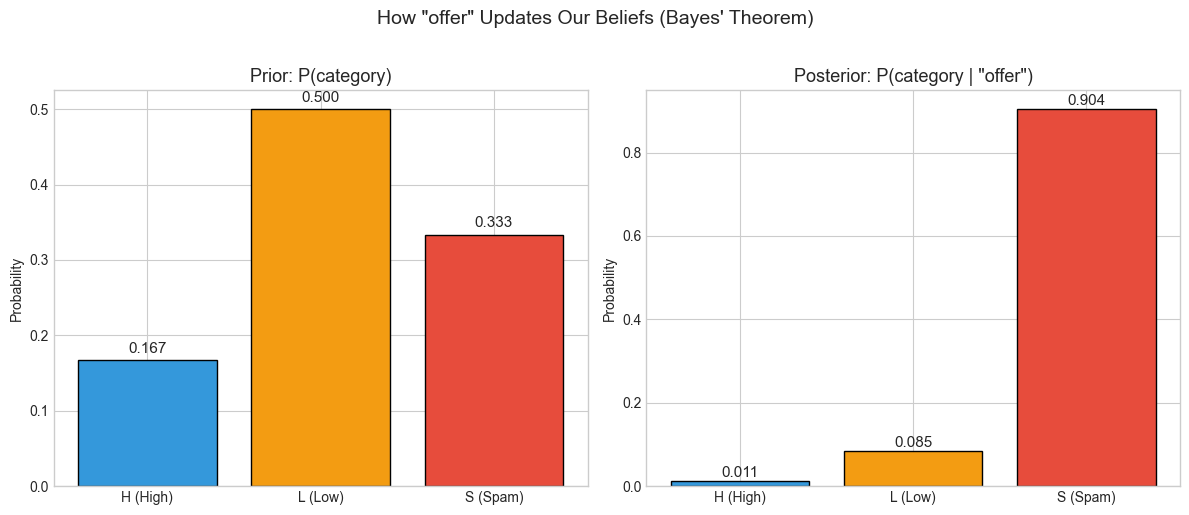

After seeing 'offer', spam probability jumps from 33.3% to 90.4%!


In [20]:
# Visualize: prior vs posterior for each category
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cats = ['H (High)', 'L (Low)', 'S (Spam)']
priors = [200/1200, 600/1200, 400/1200]

# Posterior: P(category | offer) for each
posteriors = []
for cat, data in categories.items():
    p_cat = data['total'] / N_emails
    p_offer_given_cat = data['offer'] / data['total']
    posterior = (p_offer_given_cat * p_cat) / p_offer
    posteriors.append(posterior)

colors_cat = ['#3498db', '#f39c12', '#e74c3c']

axes[0].bar(cats, priors, color=colors_cat, edgecolor='black')
axes[0].set_title('Prior: P(category)', fontsize=13)
axes[0].set_ylabel('Probability')
for i, p in enumerate(priors):
    axes[0].text(i, p + 0.01, f'{p:.3f}', ha='center', fontsize=11)

axes[1].bar(cats, posteriors, color=colors_cat, edgecolor='black')
axes[1].set_title('Posterior: P(category | "offer")', fontsize=13)
axes[1].set_ylabel('Probability')
for i, p in enumerate(posteriors):
    axes[1].text(i, p + 0.01, f'{p:.3f}', ha='center', fontsize=11)

plt.suptitle('How "offer" Updates Our Beliefs (Bayes\' Theorem)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("After seeing 'offer', spam probability jumps from 33.3% to 90.4%!")

---
## 10. SRS Revisited: Conditional Probability

Back to the SRS of 2 from {Alice, Bob, Cindy, Dave, Eva}.

From the notes:
- $P(B) = P(\text{Bob is selected})$
- $P(B|A) = P(\text{Bob is selected} | \text{Alice is selected})$

In [21]:
from itertools import combinations

people = ['Alice', 'Bob', 'Cindy', 'Dave', 'Eva']
sample_space = list(combinations(people, 2))

# P(Bob)
bob_outcomes = [p for p in sample_space if 'Bob' in p]
p_bob = len(bob_outcomes) / len(sample_space)
print(f"P(Bob selected) = {len(bob_outcomes)}/{len(sample_space)} = {p_bob:.4f}")

# P(Bob | Alice) — given Alice is selected, what's the probability Bob is too?
alice_outcomes = [p for p in sample_space if 'Alice' in p]
alice_and_bob = [p for p in sample_space if 'Alice' in p and 'Bob' in p]

p_bob_given_alice = len(alice_and_bob) / len(alice_outcomes)
print(f"P(Bob | Alice selected) = {len(alice_and_bob)}/{len(alice_outcomes)} = {p_bob_given_alice:.4f}")

print(f"\nP(Bob) = {p_bob:.4f} ≠ P(Bob|Alice) = {p_bob_given_alice:.4f}")
print(f"→ NOT independent!")
print(f"\nIntuition: If Alice fills one slot, Bob only needs to beat 3 others for 1 spot")
print(f"          instead of 4 others for 2 spots. His chances go UP.")

P(Bob selected) = 4/10 = 0.4000
P(Bob | Alice selected) = 1/4 = 0.2500

P(Bob) = 0.4000 ≠ P(Bob|Alice) = 0.2500
→ NOT independent!

Intuition: If Alice fills one slot, Bob only needs to beat 3 others for 1 spot
          instead of 4 others for 2 spots. His chances go UP.


---
## Practice Problems

Try these yourself before running the solution cells!

### Problem 1: Medical Testing

A disease affects 1% of the population. A test for the disease has:
- **Sensitivity** (true positive rate): 95% — P(test + | has disease) = 0.95
- **Specificity** (true negative rate): 90% — P(test - | no disease) = 0.90

**If someone tests positive, what's the probability they actually have the disease?**

(This is a classic Bayes' Theorem problem that surprises everyone!)

In [22]:
# YOUR WORK HERE — try to compute it by hand first!
# Then uncomment and run to check:

# p_disease = 0.01
# p_pos_given_disease = 0.95
# p_pos_given_no_disease = 1 - 0.90  # false positive rate = 0.10
# 
# p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * (1 - p_disease)
# p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos
# 
# print(f"P(disease | test+) = {p_disease_given_pos:.4f}")
# print(f"Only {p_disease_given_pos*100:.1f}% — even with a positive test!")
# print(f"\nWhy so low? Because the disease is rare (1%), so most positives are false positives.")

### Problem 2: Two Dice

You roll two fair dice. You're told the sum is 8.

**What's the probability that one of the dice shows a 3?**

Compute $P(\text{a die shows 3} | \text{sum is 8})$

In [23]:
# YOUR WORK HERE
# Hint: enumerate all outcomes where sum = 8, then count how many have a 3

# omega = [(d1, d2) for d1 in range(1,7) for d2 in range(1,7)]
# sum_8 = [(d1,d2) for d1,d2 in omega if d1+d2 == 8]
# has_3 = [(d1,d2) for d1,d2 in sum_8 if d1==3 or d2==3]
# print(f"Outcomes with sum=8: {sum_8}")
# print(f"Of those, with a 3:  {has_3}")
# print(f"P(has 3 | sum=8) = {len(has_3)}/{len(sum_8)} = {len(has_3)/len(sum_8):.4f}")

### Problem 3: Simulate Conditional Probability

Write a simulation: flip a coin 3 times. 

**Given that at least one flip was heads, what's the probability all three were heads?**

Compute $P(\text{all H} | \text{at least one H})$

In [24]:
# YOUR WORK HERE
# Theoretical: P(all H | ≥1 H) = P(all H AND ≥1 H) / P(≥1 H) = P(all H) / P(≥1 H)
#            = (1/8) / (7/8) = 1/7

# n_sims = 200_000
# flips = np.random.randint(0, 2, size=(n_sims, 3))  # 0=T, 1=H
# heads_count = flips.sum(axis=1)
# 
# at_least_one_H = heads_count >= 1
# all_H = heads_count == 3
# 
# p_all_given_at_least_one = all_H[at_least_one_H].mean()
# print(f"Simulated: P(all H | ≥1 H) = {p_all_given_at_least_one:.4f}")
# print(f"Theoretical: 1/7 = {1/7:.4f}")

---
## Quick Reference: Topic 9 Formula Sheet

| Concept | Formula |
|---------|---------|
| **Conditional probability** | $P(A|B) = \frac{P(A \cap B)}{P(B)}$ |
| **General Multiplication Rule** | $P(A \cap B) = P(B) \cdot P(A|B)$ |
| **Independence** | $P(A|B) = P(A)$, equivalently $P(A \cap B) = P(A) \cdot P(B)$ |
| **Law of Total Probability** | $P(B) = P(B|A) \cdot P(A) + P(B|A^c) \cdot P(A^c)$ |
| **Bayes' Theorem** | $P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$ |
| **Complement rule (conditional)** | $P(A^c|B) = 1 - P(A|B)$ |
| **Addition rule (conditional)** | If $A,B$ disjoint: $P(A \cup B | C) = P(A|C) + P(B|C)$ |

**Marginal probability** = totals (row or column) in a contingency table  
**Joint probability** = interior cells of a contingency table  

**Bayes' Theorem pattern:**  
Prior belief → Observe data → Updated (posterior) belief